In [1]:
# automatically reload each function when called for development
%load_ext autoreload
%autoreload 2

# Parameter Estimation

In [2]:
# Import the PNGmodel class
from codes.PNGmodel import PNGmodel

## Initialize the model
All that you need to specify for initialization is the file containing your fiducial case and the MathModel that you will use. It is assumed that the fid_corr file is a fits table with a column labeled 's' for the scale and all other columns representing the different terms of your observation vector at those scales. 

Each of the MathModels is a class stored in './codes/MathModels.py'. When initializing the PNGmodel you must first import the MathModel and pass an *instance* of it. The MathModel describes the different parameters that you are measuring and it defines what your theoretical observation vector will be. There are some predefined models in the file mentioned above, but creating a new one is straght forward. The necessary components that make up a MathModel class are described in the above mentioned file. 

In [3]:
from codes.MathModels import Y1

mod = PNGmodel(fid_corr = './inputs/fiducial.fits', 
               math_model = Y1())

Initializing...


## Load the covariance matrix

Loading the covariance matrix is very straightforward using the load_covariance() method. It assumes that the input is an npy file. One important point is that it does not *calculate* the covariance matrix, it simply loads a pre-computed matrix. As a result it is extremely important that the indices of the covariance matrix directly match the indices of the observation vector. 

In [4]:
mod.load_covariance(cov_pkg = './inputs/covariance_matrix.npy')

Loading covariance matrix...


## Load the parameterization coefficients
Our statistical model is constructed such that the theoretical observation vector is our fiducial model plus some small addition due to PNG (or other things like systematics). For example, in the case of the DR2 analysis our theoretical 2pcf, $\tilde{\xi}$, is defined as,
$$ \tilde{\xi} = \xi_{\text{fid}} + \left(A f_{\text{NL}} + B f_{\text{NL}}^2\right) + \left(\sum_R C^R K_{\text{sys}}^R + D^R (K_{\text{sys}}^R)^2\right) $$
where each coefficient is defined (and derived) independently for each element of the observation vector, i.e. each combination of $(s, \ell)$.

To add these coefficients to our PNGmodel object we use the load_fits() method. It is assumed that these files are csv files (this restriction will be lifted in time). There are two necessary columns that the file MUST have, 's' and 'term'. The 's' column corresponds to the scale (e.g. 50) and 'term' the column corresponds to the term of your observation vector (e.g. 'xi0', 'xi2', etc.). 

In [5]:
mod.load_fits('./inputs/quadfits_PNG.csv')

Loading model coefficients...
	added attribute: c1
	added attribute: c2


By default, load_fits() will take the data stored in column 'x' and store it as a PNGmodel attribute so that it can be accessed with mod.x. This becomes problematic if the names of the columns representing the coefficients differs from the names that represent these coefficients within the chosen MathModel. For example, I used the same function to generate all of my quadratic fits, and so all the files, PNG and systematics alike, have the same column labels of c1 and c2. We can avoid overwriting the mod.c1 and mod.c2 values when we load more fits by using the passing something to the 'mapper' option in load_fits(). This mapper is a dictionary that maps the column names to attribute names. Thus, to load the three sets of Ksys coefficients...

In [6]:
mod.load_fits('./inputs/quadfits_KsysSGC.csv', mapper={'c1': 'pvar_par_B1', 'c2': 'pvar_par_A1'})
mod.load_fits('./inputs/quadfits_KsysDEC.csv', mapper={'c1': 'pvar_par_B2', 'c2': 'pvar_par_A2'})
mod.load_fits('./inputs/quadfits_KsysMZLS.csv', mapper={'c1': 'pvar_par_B3', 'c2': 'pvar_par_A3'})

Loading model coefficients...
	added attribute: pvar_par_B1
	added attribute: pvar_par_A1
Loading model coefficients...
	added attribute: pvar_par_B2
	added attribute: pvar_par_A2
Loading model coefficients...
	added attribute: pvar_par_B3
	added attribute: pvar_par_A3


Lastly, there is no limit to the number of columns these files can have. If you had a file containing columns for every coefficient that is in the model, then they could all be loaded in one line.

## Run the mcmc sampling and save output

Running the MCMC and storing the output is all wrapped into one method called run_sampling(). It has many optional parameters that are fully documented in the PNGmodel.py file but the most important features are demonstrated below. When we run the sampling we can specify min_type='data' to indicate that we are giving it a true observed data set which we will pass to data_obs. This data_obs file is assumed to be in the same format as the fid_corr which was passed at initialization. We must also specify the output file for the chain with 'fname_chain'.

By design, this PNGmodel class is built to function regardless of which MathModel is chosen, allowing this PNGmodel class to very easily be used in a wide number of applications. As a result, there are some things that cannot feasibly be stored in a PNGmodel object because they contain scientific/physical information, but also cannot be hard coded into the MathModel itself beause their values may change depending on the set of data you are testing on, for example, the effective redshift of the observed data. These types of values must be defined for every MathModel class (this is described in their python file). To see what values you need to give to the model at runtime, use the show_missing_attributes() method.

In [7]:
mod.show_missing_attributes()

Must pass the following as a dictionary to 'run_sampling':
['Om_m0_g', 'Om_m0_h', 'z_eff', 'z_fid', 'z_halo']


Therefore when we call the run_sampling() method we must also pass the values of the above parameters as **kwargs (in dictionary form). 

NOTE: all of the chain output text files are saved on github so if you don't want to rerun these steps, you can skip to plotting below. 

Observable will have 108 pts
Exploring parameter space...


100%|██████████| 20000/20000 [01:18<00:00, 256.36it/s]


fNL = -14.88 + 4.85 - 5.6
b1g = 1.91 + 0.05 - 0.05
b1h = 1.94 + 0.04 - 0.04
b1gfid = 1.94 + 0.04 - 0.04
ph = 0.99 + 0.1 - 0.1
pg = 1.01 + 0.1 - 0.1
KsysSGC = 2.74 + 5.3 - 5.3
KsysDEC = 6.89 + 5.42 - 5.45
KsysMZLS = -7.27 + 5.65 - 5.66


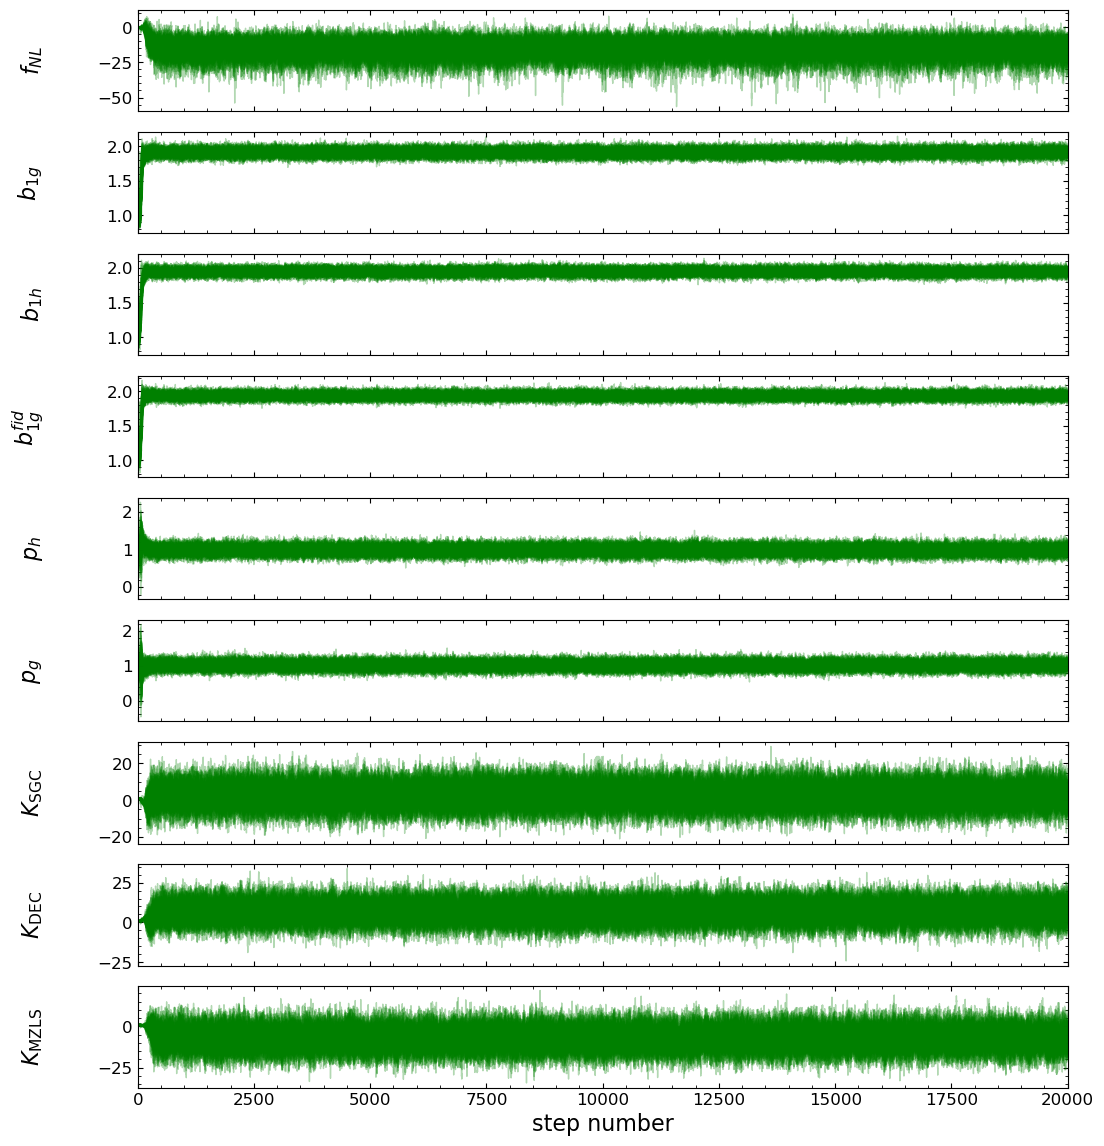

In [8]:
mod.run_sampling(min_type='data', # min_type must be the first argument
                 fname_chain=f'./outputs/testchain.txt', # fname_chain must be the second argument
                 data_obs = f'./inputs/observation.fits', # must provide data if min_type='data'
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089})

## More on Priors

Notice that we have not mentioned anything about priors on our parameters of interest, despite us already running a chain. Each MathModel is created with a set of parameter defaults that are given to the PNGmodel at initialization. These defaults refer to many things, including the priors applied to each POI. Since these priors are usually well motivated and thus less likely to change with every run, then these defaults are used when we run sampling. Of course, these priors can change from run to run (e.g. fiducial bias is different for LRGs and QSOs). To allow for updates to the priors, we can use the *update_prior* option when running run_sampling(). The value passed must be a dictionary whose keys correspond to the parameter of interest whose prior we are updating with the respective value being a length-three list of the form [$x$, $y$, 'type']. For gaussian priors the list is [$\mu$, $\sigma$, 'gauss'], and for uniform priors the list is [$low$, $high$, 'flat']. The log_prior function is defined each time run_sampling() is called and so any parameter of interest can have any type of prior. For example, if we want to give the galaxy bias a gaussian prior (the default is [$0.5$, $4$, 'flat']) and leave all other priors to their defualt values we can run: 

Observable will have 108 pts
Exploring parameter space...


100%|██████████| 20000/20000 [01:20<00:00, 246.95it/s]


fNL = -15.84 + 5.23 - 6.0
b1g = 1.87 + 0.05 - 0.05
b1h = 1.94 + 0.04 - 0.04
b1gfid = 1.9 + 0.04 - 0.04
ph = 0.99 + 0.1 - 0.1
pg = 1.01 + 0.1 - 0.1
KsysSGC = 2.61 + 5.3 - 5.31
KsysDEC = 7.04 + 5.37 - 5.46
KsysMZLS = -7.29 + 5.62 - 5.68


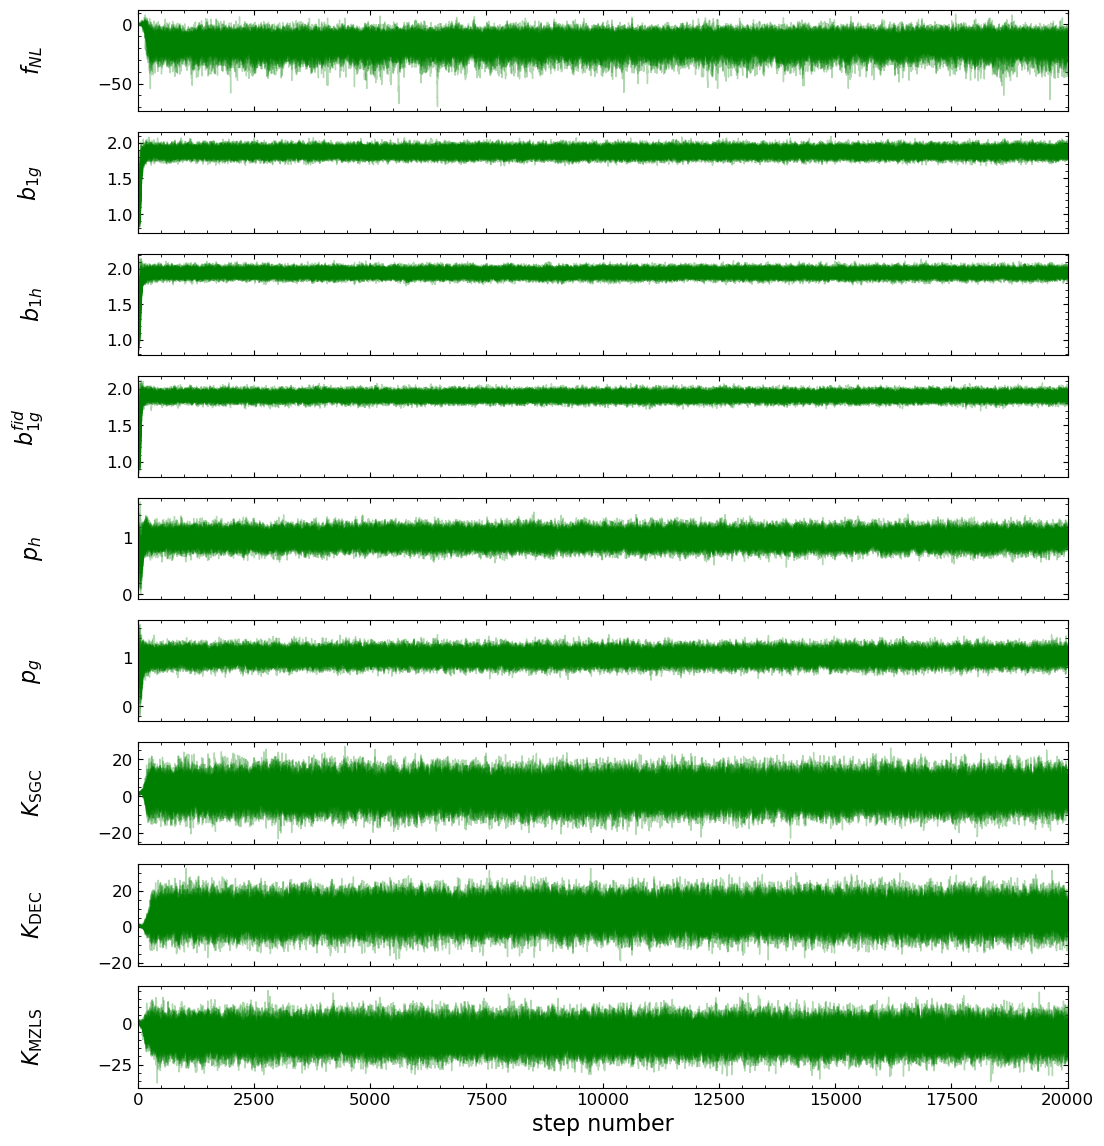

In [9]:
mod.run_sampling(min_type='data', # min_type must be the first argument
                 fname_chain=f'./outputs/testchain_update_prior_b1gfid.txt', # fname_chain must be the second argument
                 data_obs = f'./inputs/observation.fits', # must provide data if min_type='data'
                 update_priors = {'b1gfid':[1.90, 0.04, 'gauss']},
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089})

## Modifying the observation vector

It is common to want to explore the effect of modifying the observation vector without changing what data builds up your model. Due to this, it is possible to mask out various parts of the model when executing run_sampling with various optional arguments. To deal with various scale cuts there are still the original options of 's_min', 's_max', and 's_cutwindow', which by default are set to None, meaning no scales are masked. There is a fourth optional argument, 'exclude', which will mask out any terms that are passed (in a list) to it. This argument defaults to None as well meaning the two chains we ran above used the full range of scales available in the data, (50-400), and all terms (monopole, quadrupole, hexadecapole). 

As an example, we could run the MCMC on the same set of data, while only using the monopole of the 2pcf, setting the maximum scale to be 380 $h^{-1}$Mpc, and masking out the BAO region. 

Observable will have 29 pts
Exploring parameter space...


100%|██████████| 20000/20000 [01:15<00:00, 265.71it/s]


fNL = -11.62 + 6.92 - 7.41
b1g = 1.82 + 0.06 - 0.06
b1h = 1.94 + 0.04 - 0.04
b1gfid = 1.94 + 0.04 - 0.04
ph = 0.99 + 0.1 - 0.1
pg = 1.01 + 0.1 - 0.1
KsysSGC = 1.45 + 6.75 - 6.79
KsysDEC = 4.7 + 6.94 - 7.05
KsysMZLS = -3.55 + 6.54 - 6.58


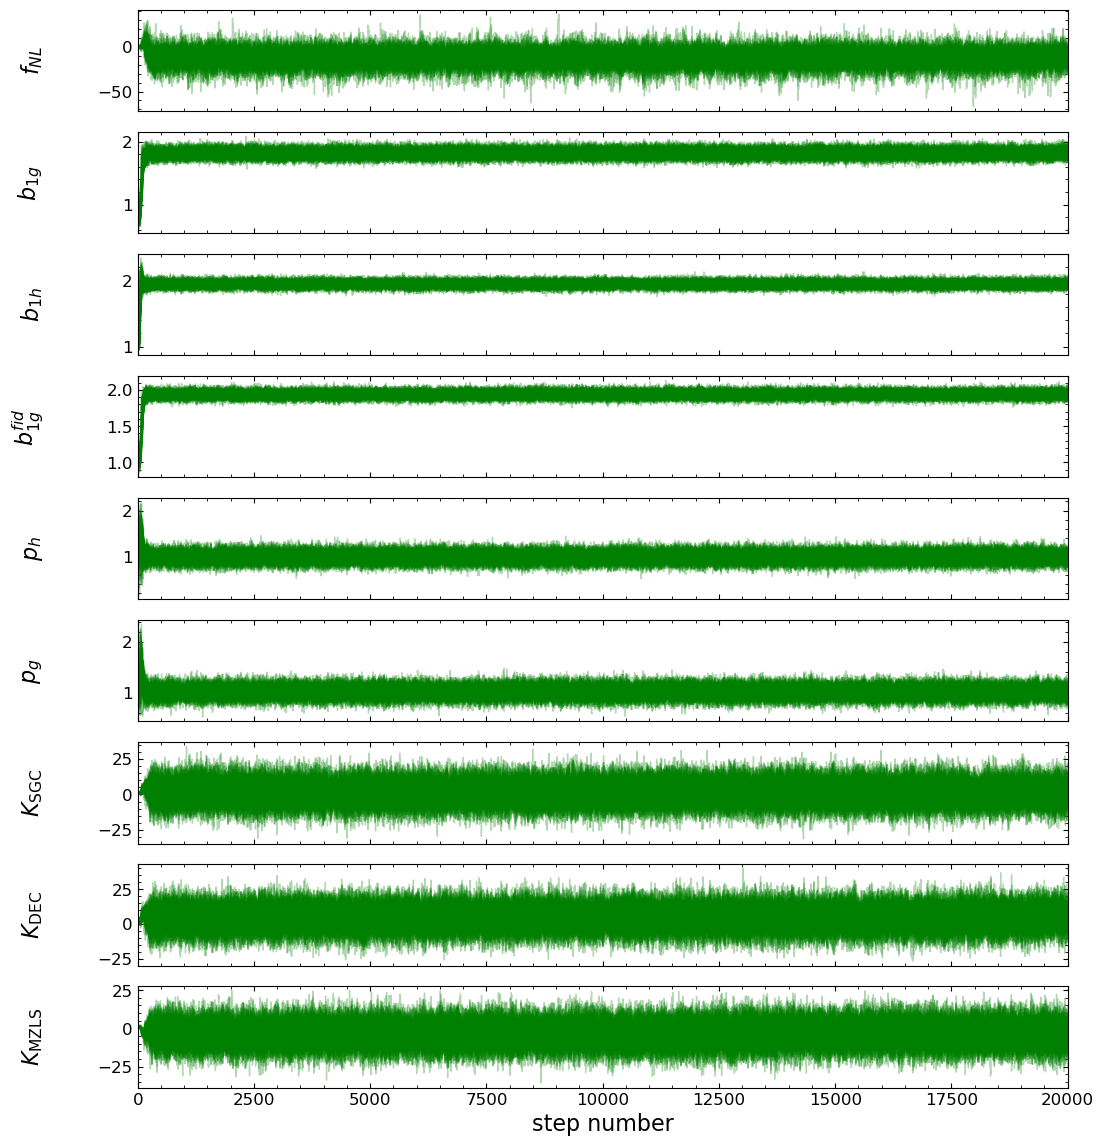

In [10]:
mod.run_sampling(min_type='data', # min_type must be the first argument
                 fname_chain=f'./outputs/testchain_scale_and_term_cuts.txt', # fname_chain must be the second argument
                 data_obs = f'./inputs/observation.fits', # must provide data if min_type='data'
                 s_max = 380,
                 s_cutwindow = [90, 130],
                 exclude=['xi2', 'xi4'],
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089})

# Making Corner Plots

There is currently one function that makes corner plots, called make_corner() and is fully documented in in './codes/corner_plots.py'. The function is really just a wrapper for pygtc.plotGTC that handles the fine tuning that one has to do when plotting multiple chains. It handles all of the indexing and fontsize rescaling automatically according to the number of chains and parameters that are being simultaneously plotted. The function only has one required argument *chains*, with many other options that are fully described in the function's definition. Many other important options are described below. 

The *chains* argument is assumed to be a list of initialized chain objects. These chain objects are defined in './codes/chain.py'. They are objects that nicely store the arrays we get from emcee, as well as all of the metadata that is stored automatically when PNGmodel.run_sampling() is called. This chain class makes dealing with the output of the MCMC much easier while also handling all the book-keeping automatically (e.g. "what effecive redshift did I use when I ran this?", "Was this *actually* run with an smax of 380?", etc.).

In [11]:
# Import the chain class
from codes.chain import chain

# Import the function to make corner plots
from codes.corner_plots import make_corner

The chain object is very easy to work with. To load it all you need to specify is the filepath to the chain a label (to be used for plotting).

In [12]:
flat = chain('./outputs/testchain.txt', label='b1g-uniform')
gauss = chain('./outputs/testchain_update_prior_b1gfid.txt', label='b1gfid update')
cuts = chain('./outputs/testchain_scale_and_term_cuts.txt', label='s and term cuts')

finished loading "b1g-uniform"
finished loading "b1gfid update"
finished loading "s and term cuts"


If you have a chain object, plotting is very simple. All you need to do is pass the list of chains you want plotted to the make_corner function. By default it will plot all of the POIs

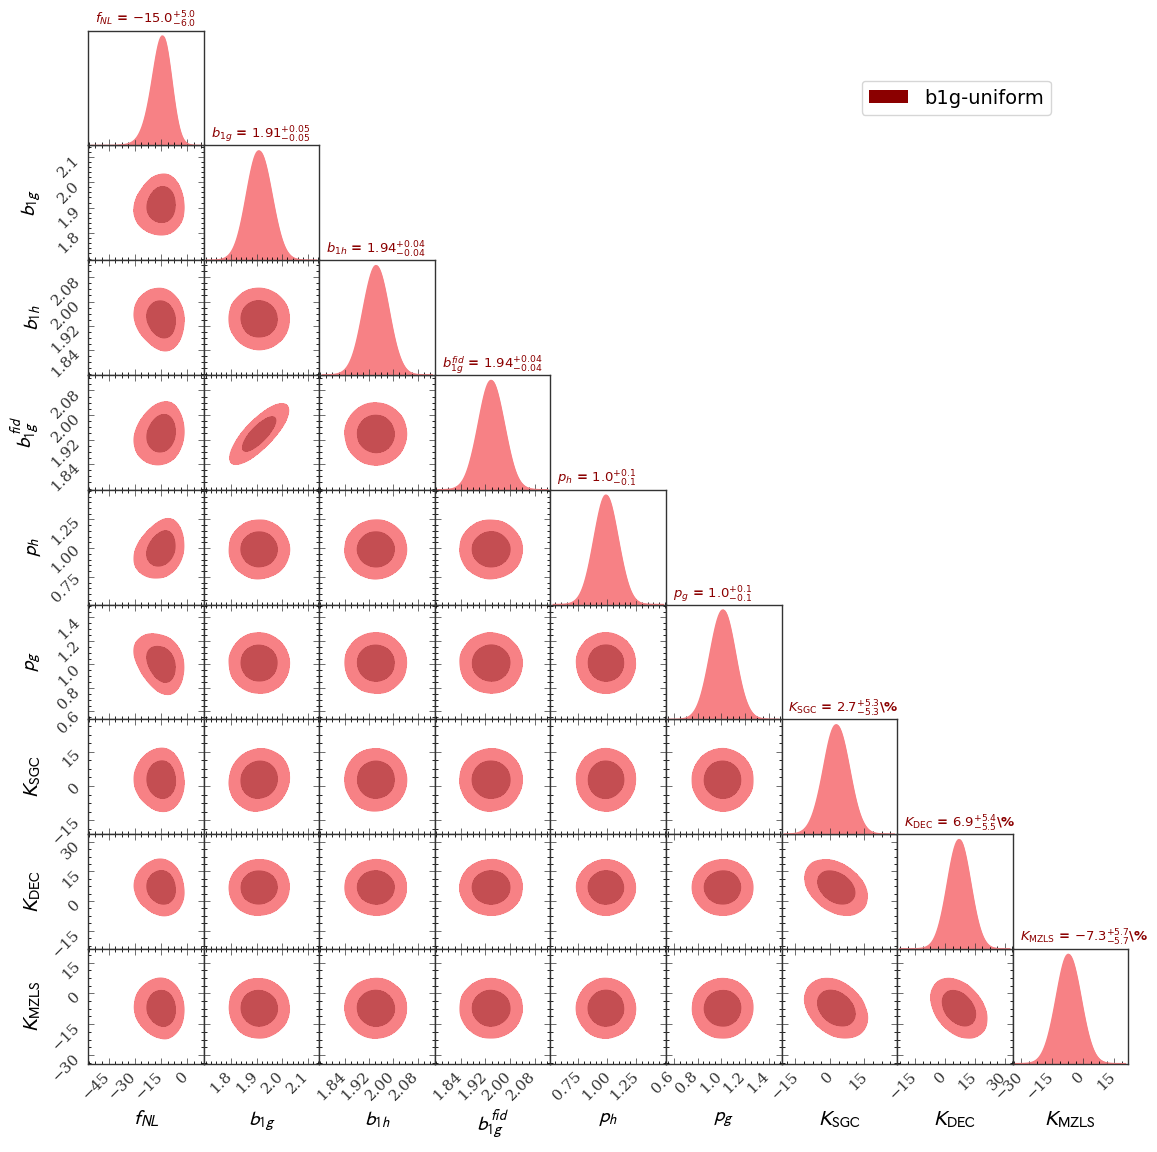

In [13]:
make_corner([flat])

If you want to plot multiple chains on the same plot, simply add more to the list. By default, colors are assigned to the chains according to their order in the list, and the font sizes automatically scale so that labels are readable.

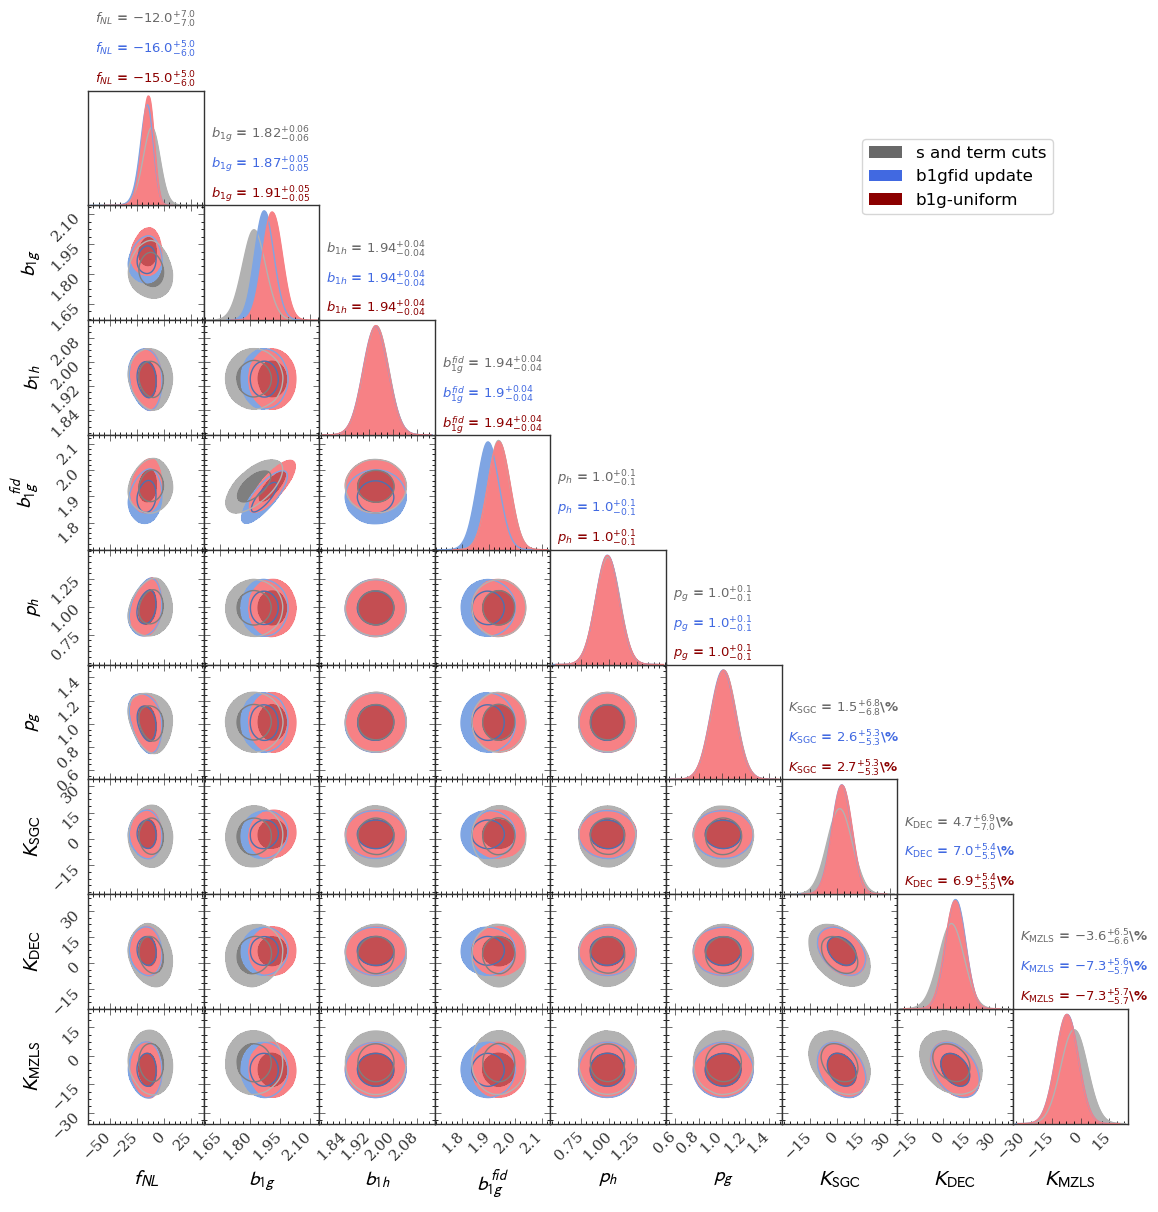

In [14]:
chains = [flat, gauss, cuts]
make_corner(chains)

Quite often I do not want to plot all of the parameters, but instead only a subset like, fnl, b1, and the ksys parameters. You can easily change what parameters you would like plotted on the fly by passing the list of parameters you would like plotted as the second argument.

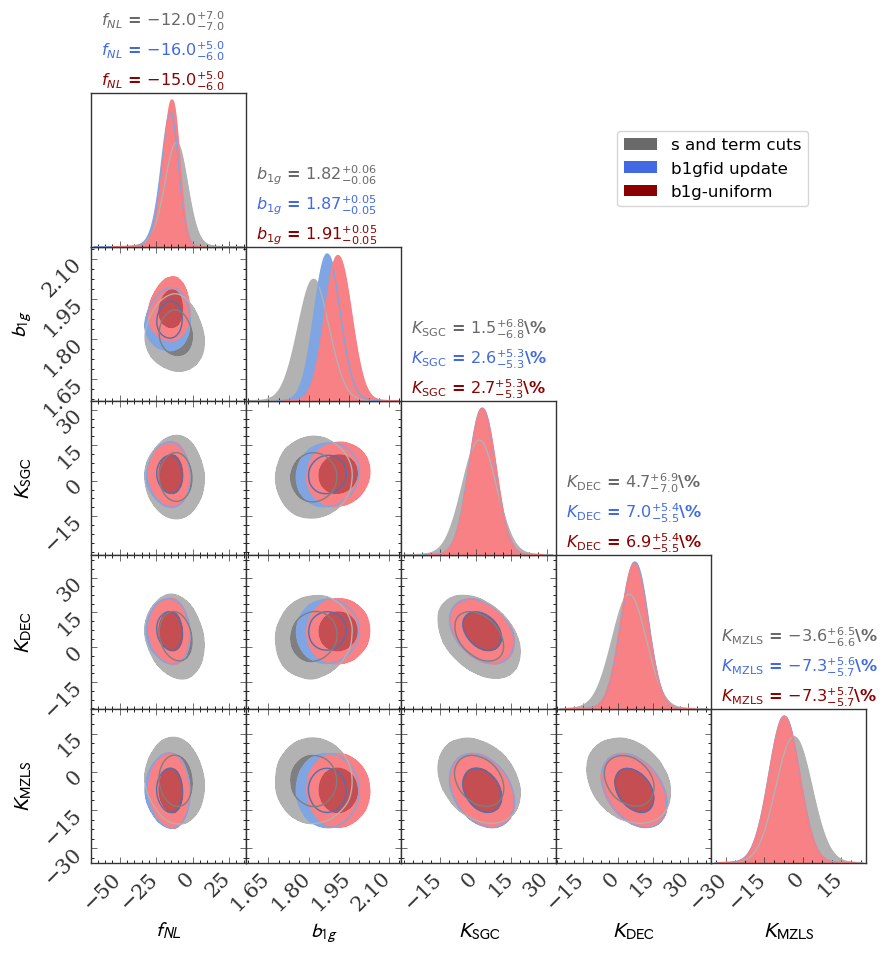

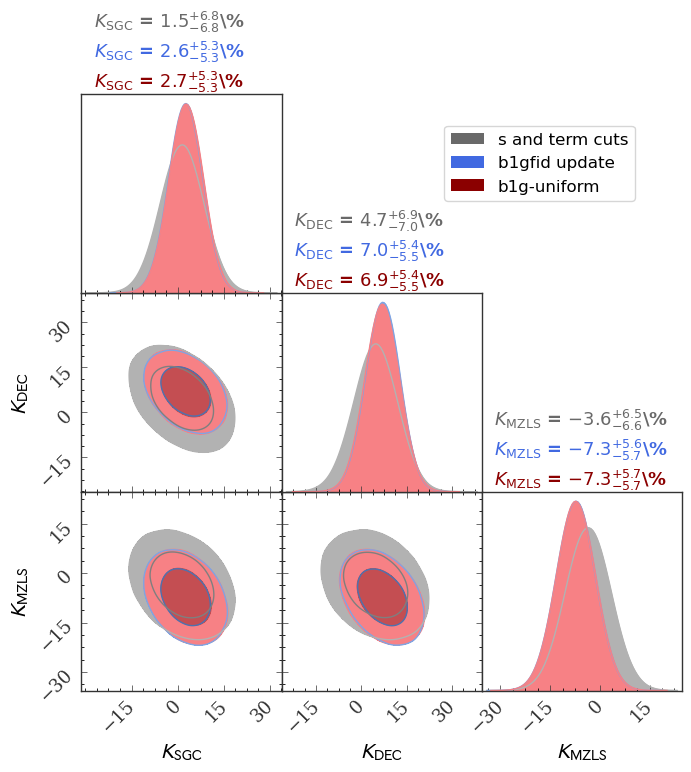

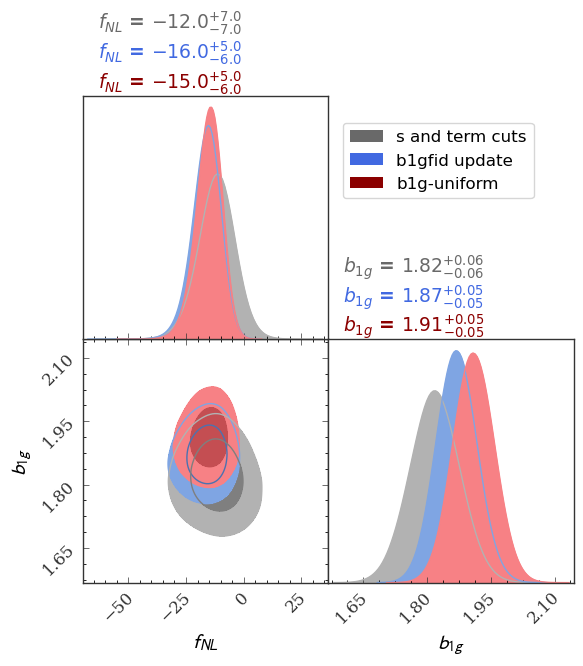

In [15]:
plists = [['fNL', 'b1g', 'KsysSGC', 'KsysDEC', 'KsysMZLS'],
          ['KsysSGC', 'KsysDEC', 'KsysMZLS'],
          ['fNL', 'b1g']]
for plist in plists:
    make_corner(chains, plist)

Let's say you have mutliple datasets (for example, LRGs and QSOs) and want to keep consistent color schemes throughout the whole project. The you can give a chain object a color that you want it to have.

In [16]:
flat.color = 'blue'
gauss.color = 'green'

Now in order to have these colors be inforced we must specify usecolors=True when we run makecorner.

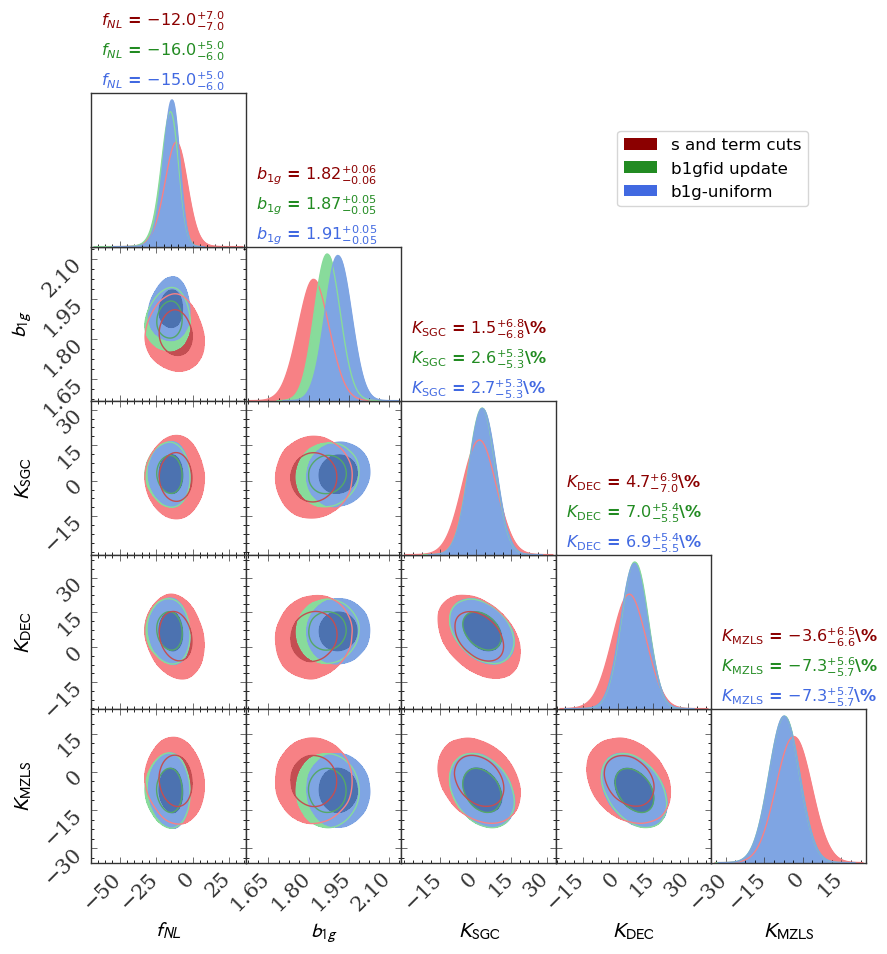

In [17]:
params = ['fNL', 'b1g', 'KsysSGC', 'KsysDEC', 'KsysMZLS']
make_corner(chains, params=params, usecolors=True)

Lastly, there are other optional parameters we can set. For example, we can give the corner plot a title by passing a string to the "title" argument. If we want to save the figure, we have to set "savefig=True" and specify the full output filename with "outfile". By default, if "savefig" is set to true and no output directory is specified it will save to './figures/'. The output directory can be changed by setting it specifically as "figdir".

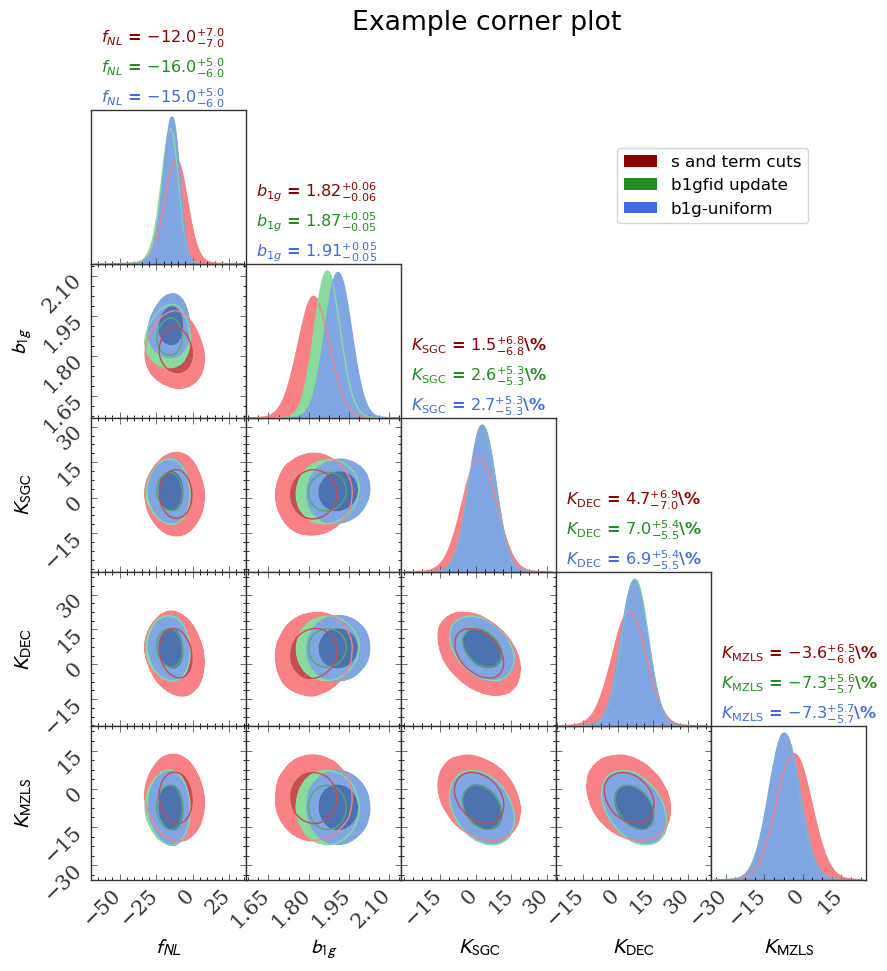

In [18]:
make_corner(chains, 
            params=params,
            usecolors=True,
            title='Example corner plot',
            savefig=True,
            outfile='example_corner.jpg')